## Contexto
Este estudo tem como objetivo construir um modelo de **regressão logística binária** para prever a probabilidade de inadimplência em solicitações de crédito. Esse tipo de modelo é bastante utilizado no setor financeiro por combinar boa capacidade preditiva com transparência nos resultados, permitindo identificar o impacto de cada variável no risco de crédito.

In [67]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.append('../src')
from utils import categorização_status
from statsmodels.discrete.discrete_model import MNLogit
import statsmodels.api as sm

warnings.filterwarnings('ignore')

In [2]:
credit_card_atributes = pd.read_csv('../data/application_record.csv')
credit_card_status = pd.read_csv('../data/credit_record.csv')


In [3]:
# Verificando dimensões dos DataFrames
print(credit_card_atributes.shape)
print(credit_card_status.shape)

(438557, 18)
(1048575, 3)


In [4]:
# junção do Dataframes
df_credit_card = pd.merge(credit_card_atributes, credit_card_status, on='ID', how='left')

In [5]:
df_credit_card.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0.0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1.0,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2.0,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3.0,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4.0,C


In [6]:
df_credit_card.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE',
       'STATUS'],
      dtype='object')

# Dicionário de dados
| Variável   | Tradução           | Descrição                                |
|------------|--------------------|------------------------------------------|
| ID         | ID DO CLIENTE      | NÚMERO DE IDENTIFICAÇÃO DO CLIENTE       |
| CODE_GENDER| GÊNERO             | GÊNERO DO CLIENTE                        |
| FLAG_OWN_CAR   | TEM UM CARRO  ?         | Y - POSSUI, N - NÃO POSSUI      |
| FLAG_OWN_REALTY  | TEM CASA ?          | Y - POSSUI, N - NÃO POSSUI        |
| CNT_CHILDREN| NÚMERO DE FILHOS          | QTD DE FILHOS                    |
| AMT_INCOME_TOTAL| RENDA ANUAL| RENDA ANUAL EM UNIDADES MONETÁRIAS DO CLIENTE |
| NAME_INCOME_TYPE| CATEGORIA DE RENDA | TIPO DE OCUPAÇÃO           |
| NAME_EDUCATION_TYPE| TIPO DE EDUÇÃO | NÍVEL DE FORMAÇÃO EDUCACIONAL DO CLIENTE           |
| NAME_FAMILY_STATUS | STATUS CIVIL  | STATUS CIVIL DO CLIENTE       |
| NAME_HOUSING_TYPE | TIPO DE MORADIA  | TIPO DE MORADIA DO CLIENTE(APARTAMENTO ALUGADO, CASA, COM OS PAIS)     |
| DAYS_BIRTH | ANIVERSÁRIO | CONTAGEM REGRESSIVA A PARTIR DO DIA ATUAL (0), -1 SIGNIFICA ONTEM     |
| DAYS_EMPLOYED | DIAS EMPREGADO | QUANTIDADE DE DIAS QUE O CLIENTE ESTÁ EMPREGADO SE POSITIVO SIGNIFICA QUE O CLIENTE ESTÁ DESEMPREGADA |
| FLAG_MOBIL | TELEFONE CELULAR | POSSUI TELEFONE CELULAR |
| FLAG_WORK_PHONE | TELEFONE CELULAR CORPORATIVO | POSSUI TELEFONE CELULAR CORPORATIVO |
| FLAG_WORK_PHONE | TELEFONE FIXO | POSSUI TELEFONE FIXO |
| FLAG_EMAIL | E-MAIL| POSSUI UM E-MAIL|
| OCCUPATION_TYPE | PROFISSÃO | PROFISSÃO DO CLIENTE|
| CNT_FAM_MEMBERS| MEMBROS DA FAMÍLIA | QUANTIDADE DE MEMBROS NA FAMÍLIA|
| MONTHS_BALANCE| MES DE REGISTRO | MÊS EM QUE O REGISTRO FOI FEITO 0 MÊS ATUAL -1 UM MÊS ANTES E ETC.|
| STATUS | STATUS DO CRÉDITO | INDICA A SITUAÇÃO DO CLIENTE EM DIAS (0 - 1 A 29, 1 - 30 A 50, 2 - 60 A 89, 3 - 90 A 119, 4 - 120 A 149, 5 - MAIS DE 150 OU DÍVIDA INCOBRÁVEL, C- DIVIDA QUITADA NO MES , X - NENHUM EMPRESTIMO NO MES).|






In [7]:
df_credit_card.shape

(1179815, 20)

In [8]:
df_credit_card.dtypes

ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
MONTHS_BALANCE         float64
STATUS                  object
dtype: object

In [9]:
df_credit_card.isnull().sum()/len(df_credit_card)

ID                     0.000000
CODE_GENDER            0.000000
FLAG_OWN_CAR           0.000000
FLAG_OWN_REALTY        0.000000
CNT_CHILDREN           0.000000
AMT_INCOME_TOTAL       0.000000
NAME_INCOME_TYPE       0.000000
NAME_EDUCATION_TYPE    0.000000
NAME_FAMILY_STATUS     0.000000
NAME_HOUSING_TYPE      0.000000
DAYS_BIRTH             0.000000
DAYS_EMPLOYED          0.000000
FLAG_MOBIL             0.000000
FLAG_WORK_PHONE        0.000000
FLAG_PHONE             0.000000
FLAG_EMAIL             0.000000
OCCUPATION_TYPE        0.307614
CNT_FAM_MEMBERS        0.000000
MONTHS_BALANCE         0.340816
STATUS                 0.340816
dtype: float64

In [10]:
# removendo dados nulos da coluana alvo 'STATUS'
df_credit_card = df_credit_card.dropna(subset=['STATUS'])

In [11]:
# Valores nulos após remoção na coluna 'STATUS
df_credit_card.isnull().sum()/len(df_credit_card)

ID                     0.000000
CODE_GENDER            0.000000
FLAG_OWN_CAR           0.000000
FLAG_OWN_REALTY        0.000000
CNT_CHILDREN           0.000000
AMT_INCOME_TOTAL       0.000000
NAME_INCOME_TYPE       0.000000
NAME_EDUCATION_TYPE    0.000000
NAME_FAMILY_STATUS     0.000000
NAME_HOUSING_TYPE      0.000000
DAYS_BIRTH             0.000000
DAYS_EMPLOYED          0.000000
FLAG_MOBIL             0.000000
FLAG_WORK_PHONE        0.000000
FLAG_PHONE             0.000000
FLAG_EMAIL             0.000000
OCCUPATION_TYPE        0.308658
CNT_FAM_MEMBERS        0.000000
MONTHS_BALANCE         0.000000
STATUS                 0.000000
dtype: float64

OCCUPATION - PROFISSSÃO FOI A ÚNICA VARIÁVEL QUE APÓS TRATAMENTO DA COLUNA ALVO STATUS, OS VALORES NULOS DESTA COLUNA SERÃO REFERENCIADOS COMO INDEFINIDO VISTO QUE É UMA COLUNA CATEGÓRICA.

In [12]:
df_credit_card['OCCUPATION_TYPE'].unique()

array([nan, 'Security staff', 'Sales staff', 'Accountants', 'Laborers',
       'Managers', 'Drivers', 'Core staff', 'High skill tech staff',
       'Cleaning staff', 'Private service staff', 'Cooking staff',
       'Low-skill Laborers', 'Medicine staff', 'Secretaries',
       'Waiters/barmen staff', 'HR staff', 'Realty agents', 'IT staff'],
      dtype=object)

In [13]:
df_credit_card['OCCUPATION_TYPE'].fillna('UNDEFINED', inplace=True)

In [14]:
# Tamanho final do Dataframe
df_credit_card.shape

(777715, 20)

In [15]:
df_credit_card.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,MONTHS_BALANCE
count,7.777150e+05,777715.000000,7.777150e+05,777715.000000,777715.000000,777715.0,777715.000000,777715.000000,777715.000000,777715.000000,777715.000000
mean,5.078743e+06,0.428082,1.885348e+05,-16124.937046,57775.825016,1.0,0.231818,0.300965,0.091675,2.208837,-19.373564
std,4.180442e+04,0.745755,1.016225e+05,4104.304018,136471.735391,0.0,0.421993,0.458678,0.288567,0.907380,14.082208
min,5.008804e+06,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,1.000000,-60.000000
25%,5.044568e+06,0.000000,1.215000e+05,-19453.000000,-3292.000000,1.0,0.000000,0.000000,0.000000,2.000000,-29.000000
50%,5.069530e+06,0.000000,1.620000e+05,-15760.000000,-1682.000000,1.0,0.000000,0.000000,0.000000,2.000000,-17.000000
75%,5.115551e+06,1.000000,2.250000e+05,-12716.000000,-431.000000,1.0,0.000000,1.000000,0.000000,3.000000,-8.000000
max,5.150487e+06,19.000000,1.575000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000,0.000000


<Figure size 800x600 with 0 Axes>

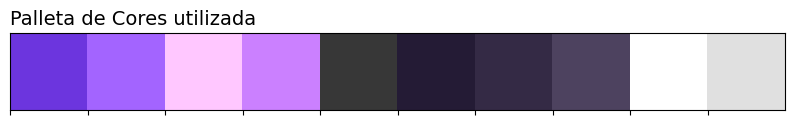

In [16]:
paleta_cores = ['#6c35de','#a364ff','#ffc7ff','#cb80ff', '#373737', '#241b35', '#342a45','#4d425f', '#ffffff', '#e0e0e0']
plt.figure(figsize=(8,6))
sns.palplot(paleta_cores)

plt.title('Palleta de Cores utilizada', loc='left', fontsize=14)
plt.show()

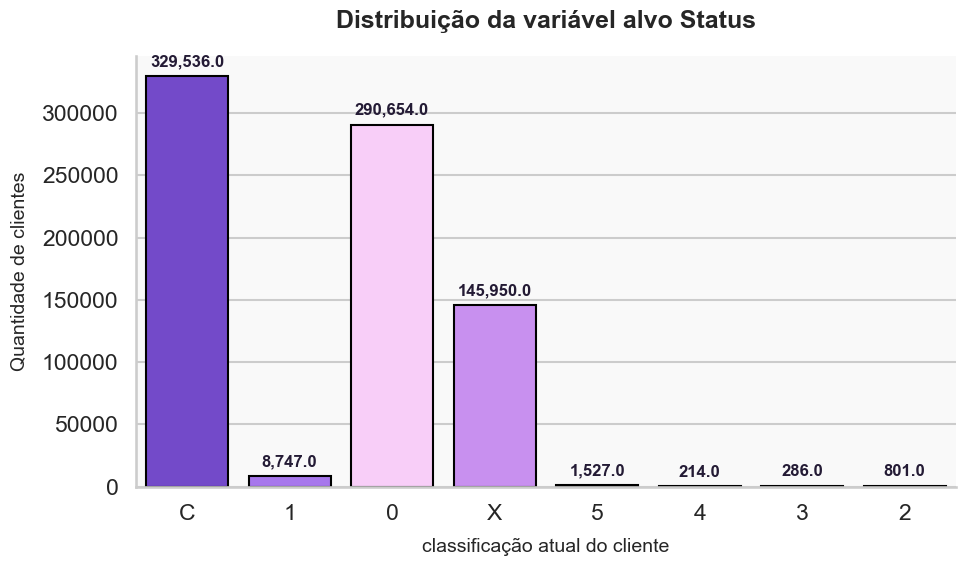

In [17]:
plt.figure(figsize=(10,6))

sns.set_style('whitegrid')
sns.set_context('talk')

ax = sns.countplot(x='STATUS', data=df_credit_card, palette=paleta_cores, edgecolor='black')
plt.title('Distribuição da variável alvo Status', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('classificação atual do cliente', fontsize=14, labelpad=10)
plt.ylabel('Quantidade de clientes', fontsize=14, labelpad=10)

# adicionando os valores acima das barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=12, fontweight='bold',
                color='#241b35', xytext=(0,5), textcoords='offset points')
    
ax.set_facecolor('#f9f9f9')
plt.gca().spines['top'].set_visible(False)  
plt.gca().spines['right'].set_visible(False)


plt.tight_layout()
plt.show()


Com a visulização acima nota-se maior presença de clientes nas categorias C = divida quitada no mês, 0 = 1 a 29 dias de atraso, X = Nenhum empréstimo no mês, sendo a categora C a mais frequente para os perfis de clientes.

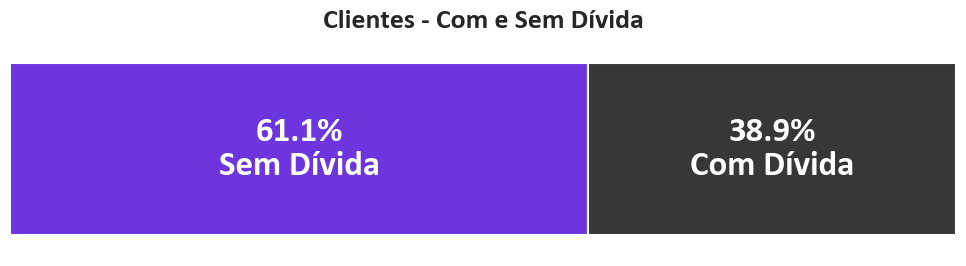

In [18]:
plt.rcParams['font.family'] = 'DejaVu Sans'
df_credit_card['DIVIDA'] = df_credit_card['STATUS'].apply(lambda x: 'SEM DIVIDA' if x in ['C', 'X'] else 'COM DIVIDA')  # Coluna que classifica dívida

percentuais = df_credit_card['DIVIDA'].value_counts(normalize=True)*100
com_divida = percentuais.get('COM DIVIDA', 0)
sem_divida = percentuais.get('SEM DIVIDA', 0)


fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(0, sem_divida, color='#6c35de')  
ax.barh(0, com_divida, left=sem_divida, color='#373737')  

ax.text(sem_divida/2, 0, f"{sem_divida:.1f}%\nSem Dívida",
        ha='center', va='center', fontsize=25, fontweight='bold', color='white', fontname='Calibri')
ax.text(sem_divida + com_divida/2, 0, f"{com_divida:.1f}%\nCom Dívida",
        ha='center', va='center', fontsize=25, fontweight='bold', color='white', fontname='Calibri')
ax.set_xlim(0, 100)  
ax.set_ylim(-0.5, 0.5)
ax.axis('off')        

plt.title("Clientes - Com e Sem Dívida", 
          fontsize=20, fontweight="bold", pad=10, fontname='Calibri')

plt.tight_layout()
plt.show()

O gáfico construído acima retrata em porcentagem a categorização entre clientes:
- Sem dívidas: junção entre as categorias X e C (Nenhum empréstimo no mês e dívida quitada)
- Com dívida: Categorias restantes

Emm uma visão macro 61,1% dos clientes se encontram sem dívidas

In [19]:
# deletando coluna DIVIDA para aplicação do modelo
df_credit_card.drop(columns=['DIVIDA'], inplace=True)

In [20]:
# Tratamento da coluna STATUS para aplicação do modelo - categorização dos casos C e X como 6 (sem dívida) e 
# os demais casos como 0, 1, 2, 3, 4 e 5 (com dívida)

df_credit_card['STATUS_CATEGORIZADO'] = df_credit_card['STATUS'].apply(categorização_status)


In [ ]:
# Ajustando os tipos das colunas para aplicação do moldelo
df_credit_card['FLAG_MOBIL'] = df_credit_card['FLAG_MOBIL'].astype('object')
df_credit_card['FLAG_WORK_PHONE'] = df_credit_card['FLAG_WORK_PHONE'].astype('object')
df_credit_card['FLAG_EMAIL'] = df_credit_card['FLAG_EMAIL'].astype('object')
df_credit_card['FLAG_PHONE'] = df_credit_card['FLAG_PHONE'].astype('object')

# Ajustando o tipo da variável alvo par inteiro
df_credit_card['STATUS_CATEGORIZADO'] = df_credit_card['STATUS_CATEGORIZADO'].astype('int64')

In [61]:
# criando um novo Dataframe para aplicação do modelo e deixando a coluna alvo já parametrizada 
df_modelo = df_credit_card.copy()
df_modelo.drop(columns=['ID', 'STATUS'], inplace=True)

In [62]:
# dumizando as variáveis categóricas
df_modelo = pd.get_dummies(df_modelo,
                           columns=['CODE_GENDER',
                                    'FLAG_OWN_CAR',
                                    'FLAG_OWN_REALTY',
                                    'NAME_INCOME_TYPE',
                                    'NAME_EDUCATION_TYPE',
                                    'NAME_FAMILY_STATUS',
                                    'NAME_HOUSING_TYPE',
                                    'FLAG_MOBIL',
                                    'FLAG_WORK_PHONE',
                                    'FLAG_PHONE',
                                    'FLAG_EMAIL',
                                    'OCCUPATION_TYPE',
                                    ],
                                    dtype=int,
                                    drop_first=True) 

In [63]:
df_modelo.head()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS_CATEGORIZADO,CODE_GENDER_M,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_UNDEFINED,OCCUPATION_TYPE_Waiters/barmen staff
0,0,427500.0,-12005,-4542,2.0,0.0,6,1,1,1,...,0,0,0,0,0,0,0,0,1,0
1,0,427500.0,-12005,-4542,2.0,-1.0,6,1,1,1,...,0,0,0,0,0,0,0,0,1,0
2,0,427500.0,-12005,-4542,2.0,-2.0,6,1,1,1,...,0,0,0,0,0,0,0,0,1,0
3,0,427500.0,-12005,-4542,2.0,-3.0,6,1,1,1,...,0,0,0,0,0,0,0,0,1,0
4,0,427500.0,-12005,-4542,2.0,-4.0,6,1,1,1,...,0,0,0,0,0,0,0,0,1,0


In [68]:
# defirindo variáveis para aplicação do modelo multinomial
x = df_modelo.drop(columns=['STATUS_CATEGORIZADO'])
y = df_modelo['STATUS_CATEGORIZADO']

X= sm.add_constant(x)


In [69]:
# estimação do modelo
modelo_credit_card = MNLogit(endog=y, exog=X).fit()

Optimization terminated successfully.
         Current function value: nan
         Iterations 12


In [70]:
modelo_credit_card.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           MNLogit Regression Results                          
===============================================================================
Dep. Variable:     STATUS_CATEGORIZADO   No. Observations:               777715
Model:                         MNLogit   Df Residuals:                   777379
Method:                            MLE   Df Model:                          329
Date:                 dom, 24 ago 2025   Pseudo R-squ.:                     nan
Time:                         17:49:40   Log-Likelihood:                    nan
converged:                        True   LL-Null:                   -8.7152e+05
Covariance Type:             nonrobust   LLR p-value:                       nan
=====================================================================================================================
                            STATUS_CATEGORIZADO=1       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
const                                                    nan        nan        nan        nan         nan         nan
CNT_CHILDREN                                             nan        nan        nan        nan         nan         nan
AMT_INCOME_TOTAL                                         nan        nan        nan        nan         nan         nan
DAYS_BIRTH                                               nan        nan        nan        nan         nan         nan
DAYS_EMPLOYED                                            nan        nan        nan        nan         nan         nan
CNT_FAM_MEMBERS                                          nan        nan        nan        nan         nan         nan
MONTHS_BALANCE                                           nan        nan        nan        nan         nan         nan
CODE_GENDER_M                                            nan        nan        nan        nan         nan         nan
FLAG_OWN_CAR_Y                                           nan        nan        nan        nan         nan         nan
FLAG_OWN_REALTY_Y                                        nan        nan        nan        nan         nan         nan
NAME_INCOME_TYPE_Pensioner                               nan        nan        nan        nan         nan         nan
NAME_INCOME_TYPE_State servant                           nan        nan        nan        nan         nan         nan
NAME_INCOME_TYPE_Student                                 nan        nan        nan        nan         nan         nan
NAME_INCOME_TYPE_Working                                 nan        nan        nan        nan         nan         nan
NAME_EDUCATION_TYPE_Higher education                     nan        nan        nan        nan         nan         nan
NAME_EDUCATION_TYPE_Incomplete higher                    nan        nan        nan        nan         nan         nan
NAME_EDUCATION_TYPE_Lower secondary                      nan        nan        nan        nan         nan         nan
NAME_EDUCATION_TYPE_Secondary / secondary special        nan        nan        nan        nan         nan         nan
NAME_FAMILY_STATUS_Married                               nan        nan        nan        nan         nan         nan
NAME_FAMILY_STATUS_Separated                             nan        nan        nan        nan         nan         nan
NAME_FAMILY_STATUS_Single / not married                  nan        nan        nan        nan         nan         nan
NAME_FAMILY_STATUS_Widow                                 nan        nan        nan        nan         nan         nan
NAME_HOUSING_TYPE_House / apartment                      nan        nan        nan        nan         nan         nan
NAME_HOUSING_TYPE_Municipal apartment                    nan        nan        nan        nan         nan         nan
NAME_HOUSING_TYPE_Office apartment            